# Simple Linear Regression – Marketing ROI Analysis

Upload `marketing_and_sales_data_evaluate_lr.csv` when prompted and run all cells.

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [17]:
from google.colab import files
uploaded = files.upload()

Saving marketing_and_sales_data_evaluate_lr.csv to marketing_and_sales_data_evaluate_lr (1).csv


In [18]:
df = pd.read_csv("marketing_and_sales_data_evaluate_lr.csv")
df.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


## Data Cleaning

In [19]:
df.info()
df.describe()

# Check missing values
df.isnull().sum()

# Clean dataset
df = df.dropna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


## Exploratory Data Analysis

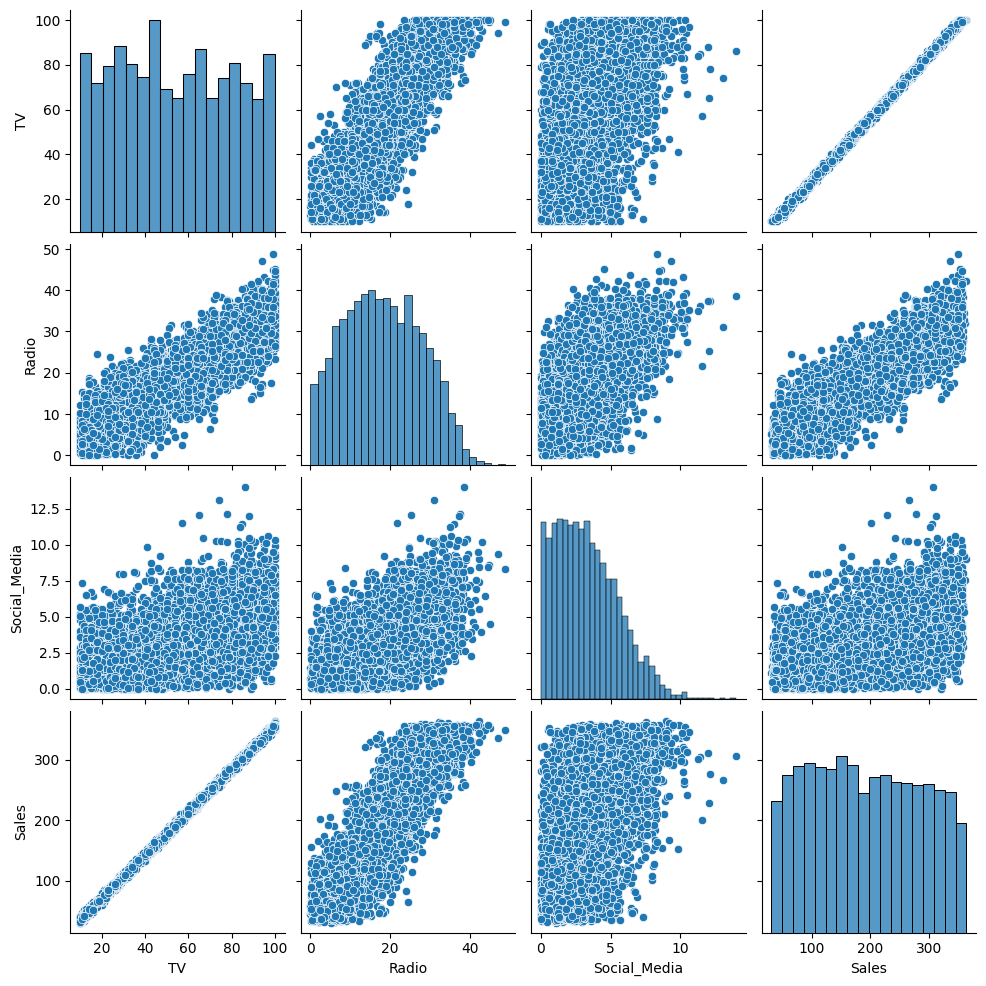

In [20]:
sns.pairplot(df)
plt.show()

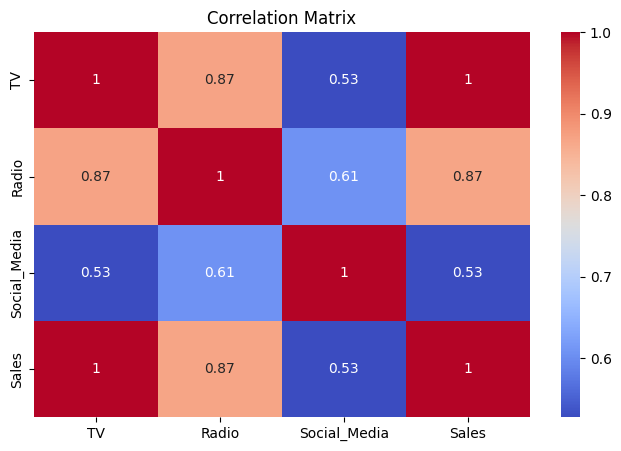

In [21]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [22]:
corr = df.corr(numeric_only=True)["Sales"].sort_values(ascending=False)
corr

,Sales
Sales,1.000000
TV,0.999497
Radio,0.868638
Social_Media,0.527446


## Build OLS Regression Model

In [23]:
X = df["TV"]   # change if another feature is strongest
y = df["Sales"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Thu, 18 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:28:58   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

In [24]:
df["Predicted_Sales"] = model.predict(X)
df.head()

,TV,Radio,Social_Media,Sales,Predicted_Sales
0,16.0,6.566231,2.907983,54.732757,56.851733
1,13.0,9.237765,2.409567,46.677897,46.167191
2,41.0,15.886446,2.913410,150.177829,145.889585
3,83.0,30.020028,6.922304,298.246340,295.473177
4,15.0,8.437408,1.405998,56.594181,53.290219


## Diagnostic Plots

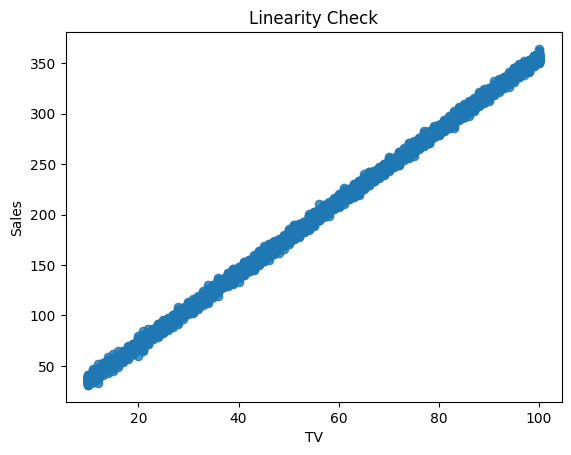

In [25]:
sns.regplot(x=df["TV"], y=df["Sales"])
plt.title("Linearity Check")
plt.show()

## Interpretation and Recommendation

In [26]:
residuals = model.resid
fitted = model.fittedvalues

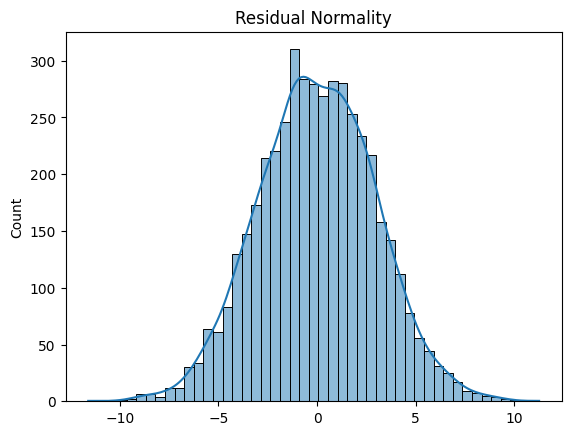

In [13]:
sns.histplot(residuals, kde=True)
plt.title("Residual Normality")
plt.show()

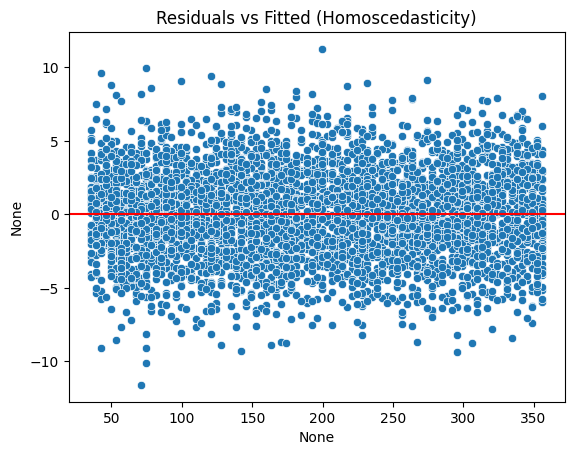

In [27]:
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color="red")
plt.title("Residuals vs Fitted (Homoscedasticity)")
plt.show()

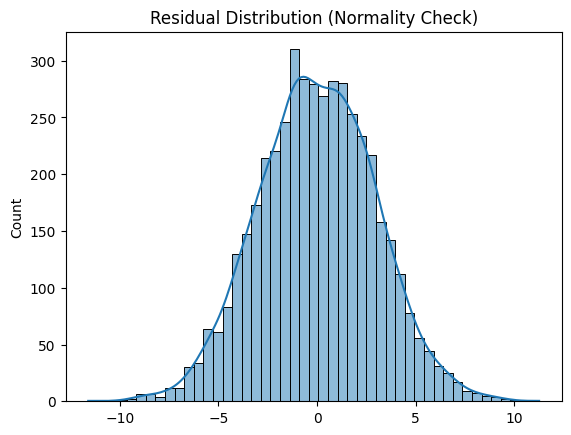

In [28]:
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution (Normality Check)")
plt.show()

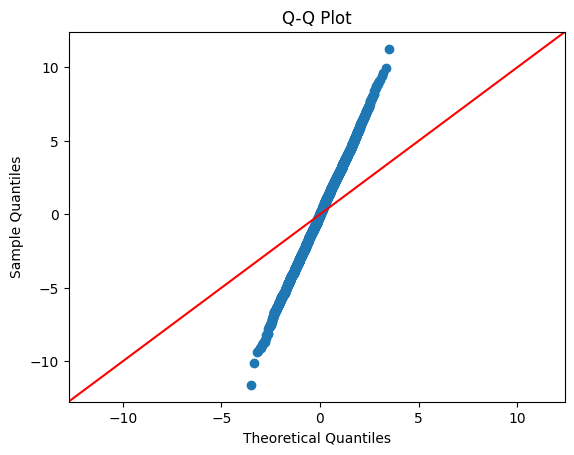

In [29]:
sm.qqplot(residuals, line="45")
plt.title("Q-Q Plot")
plt.show()

In [30]:
r2 = model.rsquared
coef = model.params["TV"]
pval = model.pvalues["TV"]

print("R-squared:", r2)
print("Coefficient:", coef)
print("P-value:", pval)

R-squared: 0.998994984518024
Coefficient: 3.5615140946411747
P-value: 0.0


In [31]:
print("""
BUSINESS INSIGHT:

- TV advertising shows the strongest relationship with Sales.
- The model explains a significant portion of sales variation (R² value).
- A positive coefficient indicates that increasing TV budget increases sales.
- P-value confirms whether this relationship is statistically significant.

RECOMMENDATION:
- Increase investment in the highest-performing channel (TV).
- Optimize or reduce lower-performing channels.
""")


BUSINESS INSIGHT:

- TV advertising shows the strongest relationship with Sales.
- The model explains a significant portion of sales variation (R² value).
- A positive coefficient indicates that increasing TV budget increases sales.
- P-value confirms whether this relationship is statistically significant.

RECOMMENDATION:
- Increase investment in the highest-performing channel (TV).
- Optimize or reduce lower-performing channels.



In [32]:
df.to_csv("cleaned_marketing_data.csv", index=False)